# Default functions

In [74]:
import networkx as nx
import random
from itertools import combinations
import matplotlib.pyplot as plt

# Initialize Simulation
L_range = (5, 25)
T = 100
simulation_time = 36000

In [75]:
# Initialize traffic data structure
traffic = []

# Simulation
def run_simulation(G, traffic, show_trip_list = False):
  shortest_paths = dict(nx.all_pairs_shortest_path(G))
  traffic.extend([[0 for _ in range(len(G.nodes()))] for _ in range(len(G.nodes()))])
  for _ in range(simulation_time):
      for _ in range(T):
          node_list = list(G.nodes())
          start, end = random.sample(node_list, 2)
          path = shortest_paths[start][end]

          # Update traffic
          for i in range(len(path) - 1):
              traffic[path[i]][path[i + 1]] += 1
  if(show_trip_list):
    print("Trip List")
    print("(", end = "")
    for i in range(len(traffic)):
      for j in range(len(traffic[i])):
        if traffic[i][j] > 0:
          print(f"(({i}, {j}), {traffic[i][j]})", end=", ")
    print(")")

In [76]:
def calculate_benefit(G, X, Y, traffic, f):
    # Calculate shortest paths using Dijkstra's algorithm
    spd_XY = nx.astar_path_length(G, source=X, target=Y)
    spd_YX = nx.astar_path_length(G, source=Y, target=X)

    # Calculate direct road distance
    d_XY = spd_XY * f
    d_YX = spd_YX * f

    def get_traffic(a, b):
      total_traffic = 0
      path = nx.shortest_path(G, a, b)
      for i in range(len(path)):
        if i+1 < len(path):
          total_traffic += traffic[path[i]][path[i+1]]
      return total_traffic

    # Benefit of connecting X and Y
    benefit_XY = (spd_XY - d_XY) * (get_traffic(X, Y) + get_traffic(Y, X))

    # Consider trips through neighbors
    for n1 in G.neighbors(X):
        spd_Xn1 = nx.astar_path_length(G, source=X, target=n1)
        spd_Yn1 = nx.astar_path_length(G, source=Y, target=n1)
        benefit_XY += max((spd_Xn1 - d_XY - spd_Yn1), 0) * (get_traffic(X, n1) + get_traffic(n1, X))

    for n2 in G.neighbors(Y):
        spd_Xn1 = nx.astar_path_length(G, source=X, target=n1)
        spd_Yn1 = nx.astar_path_length(G, source=Y, target=n1)
        benefit_XY += max((spd_Yn1 - d_YX - spd_Xn1), 0) * (get_traffic(Y, n2) + get_traffic(n2, Y))

    return benefit_XY

In [77]:
def add_roads(G, k, traffic, f, print_benefits = False):
  for road in range(k):
    benefits_matrix = [[0 for _ in range(len(G.nodes()))] for _ in range(len(G.nodes()))]

    complement_graph = nx.complement(G)
    missing_edges = complement_graph.edges()

    for edge in missing_edges:
        benefits_matrix[edge[0]][edge[1]] = calculate_benefit(G, edge[0], edge[1], traffic, f)

    benefits_list = [(i, j, benefit) for i, row in enumerate(benefits_matrix) for j, benefit in enumerate(row)]

    # Sort the list based on the benefit value in descending order
    best_road = sorted(benefits_list, key=lambda x: x[2], reverse=True)[0]
    if (print_benefits):
      print("\nBenefits updated")
      for benefit in benefits_list:
        if (benefit[2] > 0):
          print(f"({benefit[0]},{benefit[1]}) : {benefit[2]:.2f}")
    print(f"Recomended road Built ({best_road[0]}, {best_road[1]}), benefit : {best_road[2]:.2f}")
    G.add_edge(best_road[0], best_road[1], weight=nx.shortest_path_length(G,best_road[0], best_road[1])*f)

# R2

<ipython-input-78-f5c80924a2b6>:13: DeprecationWarning: nx.nx_pydot.graphviz_layout depends on the pydot package, which has known issues and is not actively maintained. Consider using nx.nx_agraph.graphviz_layout instead.

See https://github.com/networkx/networkx/issues/5723
  positions = nx.nx_pydot.graphviz_layout(G)


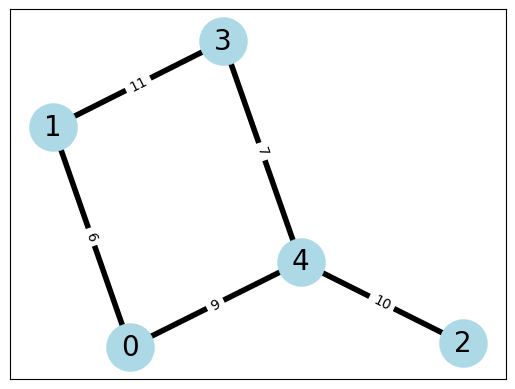

In [78]:
G=nx.Graph()

# create example graph for R2
G.add_edges_from([
    (0,1, {'weight': 6}),
     (0, 4, {'weight': 9}),
      (1, 3,{'weight': 11}),
       (2,4, {'weight': 10}),
        (3,4, {'weight': 7})])

edges = [(u, v) for (u, v, _) in G.edges(data=True)]

positions = nx.nx_pydot.graphviz_layout(G)

nx.draw_networkx_nodes(G, positions, node_size=1200, node_color='lightblue', linewidths=0.25)

nx.draw_networkx_edges(G, positions, edgelist=edges, width=4)

nx.draw_networkx_labels(G, positions, font_size=20, font_family="sans-serif")

edge_weights = nx.get_edge_attributes(G, 'weight', 'trips')

nx.draw_networkx_edge_labels(G, positions, edge_labels=edge_weights)

plt.show()

In [79]:
k = 2
f = 0.6

In [80]:
run_simulation(G, traffic, True)
add_roads(G, k, traffic, f, True)
traffic.clear()

Trip List
(((0, 1), 720998), ((0, 4), 719326), ((1, 0), 718958), ((1, 3), 359588), ((2, 4), 720273), ((3, 1), 360545), ((3, 4), 360436), ((4, 0), 720706), ((4, 2), 719433), ((4, 3), 359956), )

Benefits updated
(0,2) : 21886008.80
(0,3) : 13824569.60
(1,2) : 43196940.00
(1,4) : 17279928.00
(3,2) : 14688666.40
Recomended road Built (1, 2), benefit : 43196940.00

Benefits updated
(0,2) : 6732077.04
(0,3) : 13824569.60
(1,4) : 17625688.96
(3,2) : 8464622.00
Recomended road Built (1, 4), benefit : 17625688.96


# R3

In [81]:
N = 60
P = 0.05
k = 3

In [82]:
import copy

def random_graph(N, P):
  G = nx.gnm_random_graph(N, P)

  while not nx.is_connected(G):
    P += 0.01
    G = nx.gnm_random_graph(N, P)
  for u, v in G.edges():
    G[u][v]['weight'] = random.randint(*L_range)
  return G
G = random_graph(N, P)

In [83]:
run_simulation(G, traffic)
add_roads(copy.deepcopy(G), k, traffic, f)

Recomended road Built (10, 30), benefit : 237811290.00
Recomended road Built (10, 41), benefit : 166777365.20
Recomended road Built (17, 50), benefit : 159035836.00


# R4

In [84]:
f = 0.8

In [85]:
add_roads(copy.deepcopy(G), k, traffic, f)
traffic.clear()

Recomended road Built (10, 30), benefit : 117468645.00
Recomended road Built (10, 41), benefit : 83388682.60
Recomended road Built (24, 50), benefit : 75988013.40


The recomendations have changed a little in this case and also there is a huge change in benefit values but in some cases the recocmendations stay the same but the benefit value changes drastically.

With a higher f, shorter connections which would be less affected by the increase in f they might emerge as more beneficial compared to longer connections that were preferable at a lower f.

The benefit value theoritically will fall because by increasing the f value we will also shrink the benefit factor in the formula we remove a big chunk of value by multiplying the f. So if f is big the more benefit we take away. The same happened in our case too thats the reason for decreasing in the benefit.

# R5

In [86]:
P = 0.1

In [87]:
G = random_graph(N, P)

In [88]:
run_simulation(G, traffic)
add_roads(copy.deepcopy(G), k, traffic, f)

Recomended road Built (3, 9), benefit : 183532108.40
Recomended road Built (7, 26), benefit : 91287713.08
Recomended road Built (3, 22), benefit : 82531229.20


When comparing the benefit values of the R5 to the R3 there is a drastically decreased benefits(Almost more than halfed of what it used to be) to the recomendations because of two reasons. increae in f valye ad p value. These will affect the graph by increasing Path Options and reduced traffic on individual paths.